In [11]:
import sys
sys.path.append("..")  # needed to import dataloader.py

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataloader import MultiTaskBrainDataset
from torch.utils.data import DataLoader

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [12]:
class PPM(nn.Module):
    def __init__(self, in_channels, out_channels, bins=(1, 2, 3, 6)):
        super(PPM, self).__init__()
        self.features = nn.ModuleList()
        for bin in bins:
            self.features.append(nn.Sequential(nn.AdaptiveAvgPool2d(bin),
                                               nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                                               nn.BatchNorm2d(out_channels),
                                               nn.ReLU(inplace=True)))

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        out = [x]
        for f in self.features:
            out.append(F.interpolate(f(x), size=(h, w), mode='bilinear', align_corners=True))
        return torch.cat(out, 1)

class PSPNet(nn.Module):
    def __init__(self, num_classes=1):
        super(PSPNet, self).__init__()
        
        resnet = models.resnet18(weights=None)
        self.backbone = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
                                      resnet.bn1,
                                      resnet.relu,
                                      resnet.maxpool,
                                      resnet.layer1,
                                      resnet.layer2,
                                      resnet.layer3,
                                      resnet.layer4)
        
        self.ppm = PPM(512, 128)
        
        self.cls = nn.Sequential(nn.Conv2d(1024, 256, kernel_size=3, padding=1, bias=False),
                                 nn.BatchNorm2d(256),
                                 nn.ReLU(inplace=True),
                                 nn.Dropout2d(p=0.1),
                                 nn.Conv2d(256, num_classes, kernel_size=1))

    def forward(self, x):
        input_size = x.shape[2:]
        x = self.backbone(x)
        
        # --- MPS Compatibility Fix ---
        # current feature map is (Batch, 512, 7, 7)
        # pad to 12x12 for divisiblility by 1, 2, 3, and 6
        h, w = x.shape[2], x.shape[3]
        pad_h = (6 - h % 6) if h % 6 != 0 else 0
        pad_w = (6 - w % 6) if w % 6 != 0 else 0
        
        if pad_h > 0 or pad_w > 0: 
            x = F.pad(x, (0, pad_w, 0, pad_h))  # add padding
        # -----------------------------

        x = self.ppm(x)
        x = self.cls(x)
        return F.interpolate(x, size=input_size, mode='bilinear', align_corners=True)

In [17]:
checkpoint_dir  = os.path.join("..", "results", "segmentation", "tumor_segmentation_v1_jonah")
best_model_path = os.path.join(checkpoint_dir, "bias_field_best.pt")

checkpoint = torch.load(best_model_path, map_location=device)

model = PSPNet()
print(checkpoint.keys())
model.load_state_dict(checkpoint)
model.to(device)
model.eval()

# print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  "
#       f"(val_dice = {checkpoint['val_dice']:.4f})")

odict_keys(['backbone.0.weight', 'backbone.1.weight', 'backbone.1.bias', 'backbone.1.running_mean', 'backbone.1.running_var', 'backbone.1.num_batches_tracked', 'backbone.4.0.conv1.weight', 'backbone.4.0.bn1.weight', 'backbone.4.0.bn1.bias', 'backbone.4.0.bn1.running_mean', 'backbone.4.0.bn1.running_var', 'backbone.4.0.bn1.num_batches_tracked', 'backbone.4.0.conv2.weight', 'backbone.4.0.bn2.weight', 'backbone.4.0.bn2.bias', 'backbone.4.0.bn2.running_mean', 'backbone.4.0.bn2.running_var', 'backbone.4.0.bn2.num_batches_tracked', 'backbone.4.1.conv1.weight', 'backbone.4.1.bn1.weight', 'backbone.4.1.bn1.bias', 'backbone.4.1.bn1.running_mean', 'backbone.4.1.bn1.running_var', 'backbone.4.1.bn1.num_batches_tracked', 'backbone.4.1.conv2.weight', 'backbone.4.1.bn2.weight', 'backbone.4.1.bn2.bias', 'backbone.4.1.bn2.running_mean', 'backbone.4.1.bn2.running_var', 'backbone.4.1.bn2.num_batches_tracked', 'backbone.5.0.conv1.weight', 'backbone.5.0.bn1.weight', 'backbone.5.0.bn1.bias', 'backbone.5.0.b

/var/folders/21/6s018t752q32wrkghcj__s980000gn/T/ipykernel_64433/4063074628.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_

PSPNet(
  (backbone): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [ ]:
test_data = MultiTaskBrainDataset(os.path.join("..", "brisc2025"),
                                  mode="segmentation",
                                  train_or_test="test",
                                  augment=False,
                                  seed=42,
                                  new_height=256,
                                  new_width=256)

print(f"Test samples: {len(test_data)}")

PREFIX_MAP = {"gl": "glioma",
              "me": "meningioma",
              "pi": "pituitary",}

def infer_tumor_type(img_path: str, mask_path) -> str:
    if mask_path is None:
        return "no_tumor"
    fname = os.path.splitext(os.path.basename(img_path))[0]   # e.g. "Te_gl_0001"
    parts = fname.lower().split("_")
    for part in parts:
        if part in PREFIX_MAP:
            return PREFIX_MAP[part]
    return "tumor"   # fallback if naming convention doesn't match

# build a parallel metadata list: (img_path, mask_path, tumor_type)
sample_meta = [(img_path, mask_path, infer_tumor_type(img_path, mask_path))
               for img_path, mask_path in test_data.samples]

unique_types = sorted(set(m[2] for m in sample_meta))
print(f"Tumor types found: {unique_types}")
for t in unique_types:
    count = sum(1 for m in sample_meta if m[2] == t)
    print(f"  {t:<15} {count} samples")

Test samples: 1000
Tumor types found: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  glioma          254 samples
  meningioma      306 samples
  no_tumor        140 samples
  pituitary       300 samples


In [ ]:
def dice_score(pred_logits: torch.Tensor, target: torch.Tensor,
               threshold: float = 0.5, eps: float = 1e-6) -> float:
    probs = torch.sigmoid(pred_logits)
    preds = (probs > threshold).float()
    inter = (preds * target).sum()
    union = preds.sum() + target.sum()
    return ((2.0 * inter + eps) / (union + eps)).item()


records = []   # {idx, tumor_type, dice, image_np, true_mask_np, pred_mask_np}
loader = DataLoader(test_data, batch_size=1, shuffle=False, num_workers=0)
with torch.no_grad():
    for idx, (img, mask) in enumerate(loader):
        img_dev = img.to(device)
        mask_dev = mask.float().to(device)

        logits = model(img_dev)               # (1,1,256,256)
        d = dice_score(logits, mask_dev)

        pred_bin = (torch.sigmoid(logits) > 0.5).float().squeeze().cpu().numpy()  # (256,256)
        img_np = img.squeeze().cpu().numpy()                                     # (256,256)
        mask_np = mask.squeeze().cpu().numpy()                                    # (256,256)

        tumor_type = str(sample_meta[idx][2])

        records.append({"idx": idx,
                        "tumor_type": tumor_type,
                        "dice": d,
                        "image": img_np,
                        "true_mask": mask_np,
                        "pred_mask": pred_bin})

print(f"Inference complete — {len(records)} samples processed.")

overall_dice = np.mean([r["dice"] for r in records])
print(f"Overall mean test Dice: {overall_dice:.4f}")

Inference complete — 1000 samples processed.
Overall mean test Dice: 0.4279


In [ ]:
from collections import defaultdict

# min_or_max = min
min_or_max = max

# group by tumor type
groups = defaultdict(list)
for r in records:
    groups[r["tumor_type"]].append(r)

# pick the record with the highest/lowest Dice within each group
best_per_type = {}
for tumor_type, recs in sorted(groups.items()):
    best = min_or_max(recs, key=lambda r: r["dice"])
    best_per_type[tumor_type] = best
    print(f"  {tumor_type:20s}  best Dice = {best['dice']:.4f}  (sample idx {best['idx']})")

print(f"\n{len(best_per_type)} tumor type(s) selected for visualization.")

  glioma                best Dice = 0.7659  (sample idx 245)
  meningioma            best Dice = 0.8952  (sample idx 296)
  no_tumor              best Dice = 1.0000  (sample idx 860)
  pituitary             best Dice = 0.7443  (sample idx 740)

4 tumor type(s) selected for visualization.


/var/folders/21/6s018t752q32wrkghcj__s980000gn/T/ipykernel_64433/4245138915.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


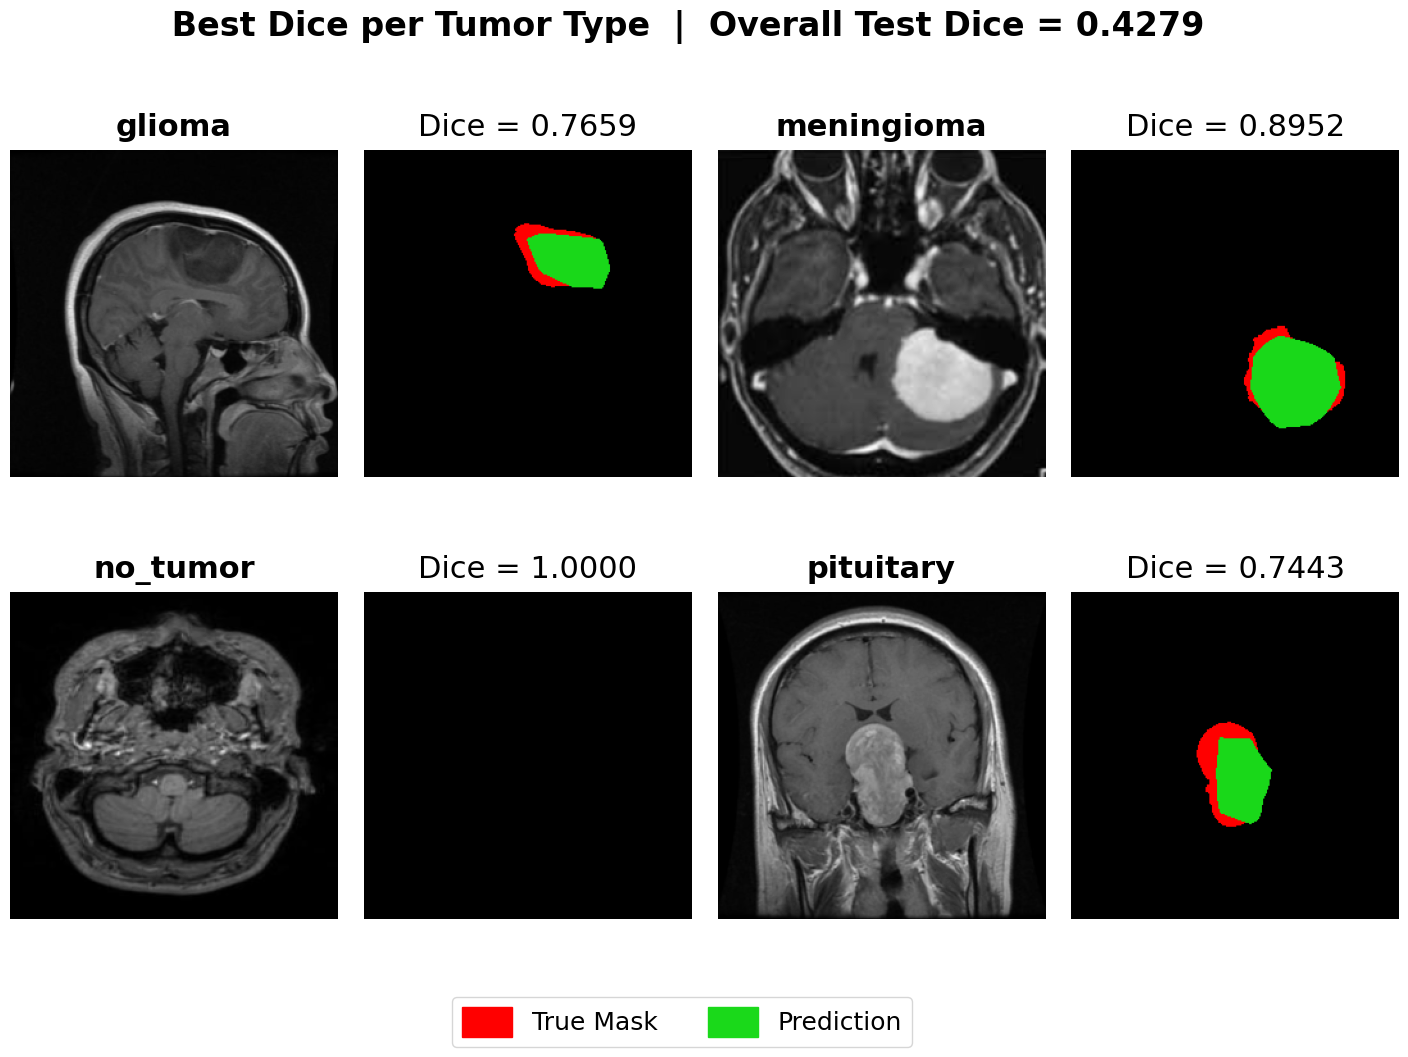

In [ ]:
def normalize_for_display(arr: np.ndarray) -> np.ndarray:
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)


fig, axes = plt.subplots(2, 4,
                         figsize=(18, 10),
                         gridspec_kw={"wspace": 0.06, "hspace": 0.35})

sorted_items = sorted(best_per_type.items())

for i, (tumor_type, rec) in enumerate(sorted_items):
    row, col = divmod(i, 2)
    ax_mri  = axes[row, col * 2]
    ax_mask = axes[row, col * 2 + 1]

    true_mask = rec["true_mask"]
    pred_mask = rec["pred_mask"]

    ax_mri.imshow(normalize_for_display(rec["image"]), cmap="gray", vmin=0, vmax=1)
    ax_mri.set_title(f"{tumor_type}", fontsize=22, fontweight="bold", pad=10)

    # mask + prediction overlay
    rgb = np.zeros((*true_mask.shape, 3), dtype=np.float32)
    rgb[:, :, 0] = true_mask  # red channel only
    rgb[pred_mask == 1] = [0.10, 0.85, 0.10]  # green prediction on top
    ax_mask.imshow(rgb, vmin=0, vmax=1)
    ax_mask.set_title(f"Dice = {rec['dice']:.4f}", fontsize=22, pad=10)

    for ax in (ax_mri, ax_mask):
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

legend_patches = [mpatches.Patch(color="red",label="True Mask"),
                  mpatches.Patch(color=(0.10, 0.85, 0.10), label="Prediction")]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=18, frameon=True, bbox_to_anchor=(0.5, -0.03),
           handlelength=2, handleheight=1.5)

fig.suptitle(f" Best Dice per Tumor Type  |  Overall Test Dice = {overall_dice:.4f}",
             fontsize=24, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("best_per_tumor_type.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print(f"{'Tumor Type':<22} {'N':>5} {'Mean Dice':>10} {'Std Dice':>10} {'Min':>8} {'Max':>8}")
print("-" * 68)
for tumor_type, recs in sorted(groups.items()):
    dices = [r["dice"] for r in recs]
    print(f"{tumor_type:<22} {len(dices):>5} "
          f"{np.mean(dices):>10.4f} {np.std(dices):>10.4f} "
          f"{np.min(dices):>8.4f} {np.max(dices):>8.4f}"
    )
print("-" * 68)
all_dices = [r["dice"] for r in records]
print(f"{'OVERALL':<22} {len(all_dices):>5} "
      f"{np.mean(all_dices):>10.4f} {np.std(all_dices):>10.4f} "
      f"{np.min(all_dices):>8.4f} {np.max(all_dices):>8.4f}")

Tumor Type                 N  Mean Dice   Std Dice      Min      Max
--------------------------------------------------------------------
glioma                   254     0.2971     0.2435   0.0000   0.7659
meningioma               306     0.5219     0.2388   0.0000   0.8952
no_tumor                 140     0.8000     0.4000   0.0000   1.0000
pituitary                300     0.2689     0.1978   0.0000   0.7443
--------------------------------------------------------------------
OVERALL                 1000     0.4279     0.3173   0.0000   1.0000
